lambdadiv = 0.023871953661760082
lambdamid = 0.004259277287955816
lambdamid_w_e = 0.004631176798772832
udiv_avg = 1.0803520480207984
lambda_avg = 0.004296421435288494


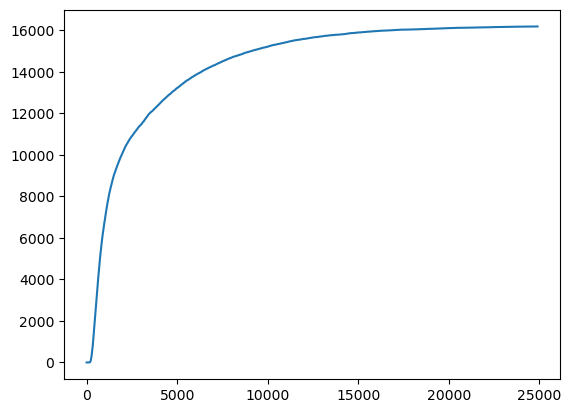

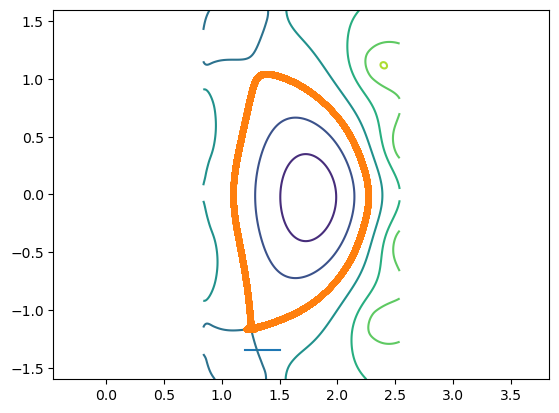

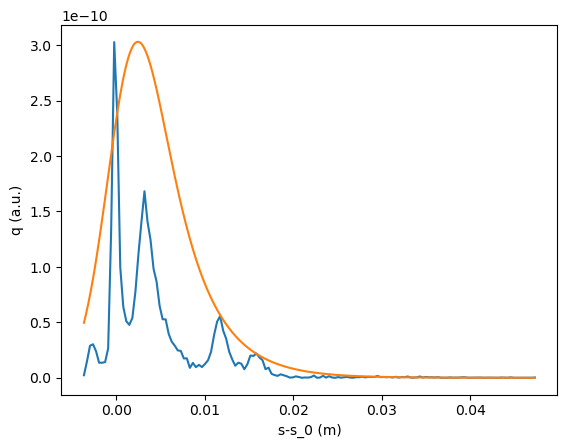

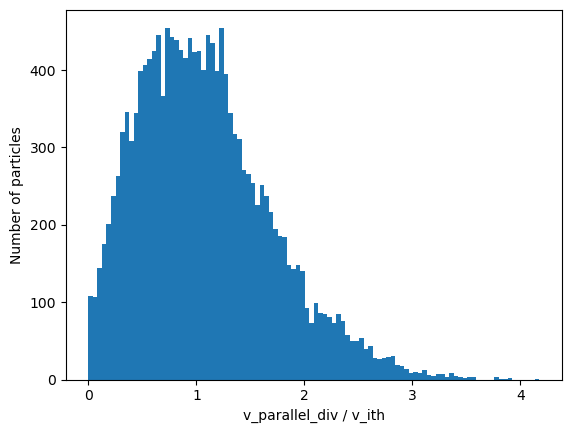

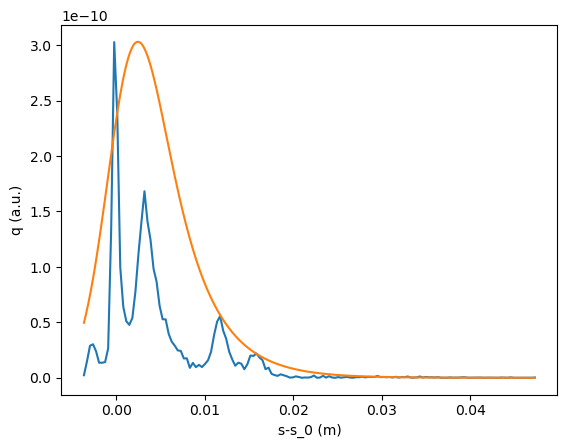

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from scipy.special import erfc

# =========================
# Load data
# =========================
p = np.loadtxt("./test_hit_div")
hit_t = np.loadtxt("test_hit_div_t")
Z = np.loadtxt("Z.dat")
ini_p = np.loadtxt("initial_posi")

psi_a = 0
number_of_beams = 150
dt = 1500e-10
mi = 2 * 1.6726e-27
e = 1.6e-19
T = 200
vth = np.sqrt(T * e / mi)

# =========================
# Divertor plate definition
# =========================
r1 = 1.2
z1 = 0.25773 + Z[0]
r2 = 1.5
z2 = 0.25773 + Z[0]

m = (z2 - z1) / (r2 - r1)
b = z1 - m * r1

R_div = np.linspace(r1, r2, 400)
Z_div = np.linspace(z1, z2, 400)

# =========================
# Load fields
# =========================
R = np.loadtxt("R.dat")
Z = np.loadtxt("Z.dat")
psi = np.loadtxt("psi_p.dat")
phi = np.loadtxt("phisolps.dat")

psip = psi.T
phip = phi.T

# zero phi
phip[:, :] = 0

# =========================
# Hit count
# =========================
hit_num = np.zeros(int(np.max(hit_t)))

for i in range(len(hit_t)):
    if hit_t[i] != 0:
        hit_num[int(hit_t[i]) - 1] += 1

for i in range(1, len(hit_num)):
    hit_num[i] += hit_num[i - 1]

plt.plot(hit_num)
plt.figure()

# =========================
# Midplane and gradients
# =========================
zmid_id = np.argmin(np.abs(Z))
Mid_z = Z[zmid_id]

Rmid_id = len(R) // 2

sgin_of_psi = (psip[-1, zmid_id] - psip[Rmid_id, zmid_id]) / abs(psip[-1, zmid_id] - psip[Rmid_id, zmid_id])

dR = R[1] - R[0]
dZ = Z[1] - Z[0]

dpdR, dpdZ = np.gradient(psip, dZ, dR)
gradpsiabs = np.sqrt(dpdR**2 + dpdZ**2)

# =========================
# X-point
# =========================
sub = gradpsiabs[1:-2, 4:zmid_id-5]
Z_x_id, R_x_id = np.unravel_index(np.argmin(sub), sub.shape)

R_x_id += 1
Z_x_id += 4

R_x = R[R_x_id]
Z_x = Z[Z_x_id]

# =========================
# Interpolators
# =========================
f = RegularGridInterpolator((R, Z), psip)
g = RegularGridInterpolator((R, Z), gradpsiabs)
phis = RegularGridInterpolator((R, Z), phip)

# =========================
# Find R_m_a
# =========================
for i in range(len(R)//2, len(R)):
    if (psip[i-1, zmid_id] - psi_a) * (psip[i, zmid_id] - psi_a) <= 0:
        R_m_a = (R[i-1]*abs(psip[i, zmid_id] - psi_a) + R[i]*abs(psip[i-1, zmid_id] - psi_a)) / \
                abs(psip[i, zmid_id] - psip[i-1, zmid_id])

        gradpsim = (gradpsiabs[i-1, zmid_id]*abs(psip[i, zmid_id] - psi_a) +
                    gradpsiabs[i, zmid_id]*abs(psip[i-1, zmid_id] - psi_a)) / \
                   abs(psip[i, zmid_id] - psip[i-1, zmid_id])
        idx_R_a = i
        break

R_M_a = 2.1177

# Divertor intersection
vals = np.array([f((R_div[i], Z_div[i])) for i in range(len(R_div))])
idx_R_div = np.argmin(np.abs(vals))

R_inter = R_div[idx_R_div]
Z_inter = Z_div[idx_R_div]

gradpsidiv = g((R_inter, Z_inter))

# =========================
# Particle loop
# =========================
Ep = []
dpsi = []
Rim = []
udiv = []
Rim_w_e = []

number_of_particles = 0

for i in range(len(p)):
    if p[i, 1] != 0:
        number_of_particles += 1
        dp = p[i, 0] - psi_a
        dpsi.append(dp)

        rim = sgin_of_psi * dp / gradpsim
        Rim.append(rim)

        Rim_w_e.append(rim * p[i, 2])
        Ep.append(p[i, 2])
        udiv.append(abs(p[i, 1]))

dpsi = np.array(dpsi)
Rim = np.array(Rim)
Rim_w_e = np.array(Rim_w_e)
Ep = np.array(Ep)
udiv = np.array(udiv)

# =========================
# Plots
# =========================
plt.plot([r2, r1], [z2, z1])
plt.contour(R, Z, psi)
plt.plot(ini_p[:, 0], ini_p[:, 1], '.', linestyle='None')
plt.axis('equal')

# =========================
# Lambda calculations
# =========================
Ridiv = dpsi / gradpsidiv

lambdadiv = np.sum(np.abs(Ridiv)) / len(dpsi)
lambdamid = np.sum(np.abs(Rim)) / len(dpsi)
lambdamid_w_e = np.sum(np.abs(Rim_w_e)) / np.sum(Ep)

print("lambdadiv =", lambdadiv)
print("lambdamid =", lambdamid)
print("lambdamid_w_e =", lambdamid_w_e)

# =========================
# Heat flux profile
# =========================
R_midgrid = np.linspace(np.min(Rim)-1e-4, np.max(Rim)+1e-4, number_of_beams+1)
dRmid = (R_midgrid[-1] - R_midgrid[0]) / number_of_beams

R_beam = 0.5 * (R_midgrid[:-1] + R_midgrid[1:])
q_mid = np.zeros(len(R_beam))

for i in range(len(dpsi)):
    pp = int(np.floor((Rim[i] - np.min(R_midgrid)) / dRmid))
    if 0 <= pp < len(q_mid):
        q_mid[pp] += Ep[i] / dRmid

q0_guess = np.max(q_mid)

start_guess = [2.4*q0_guess, 0, 0.9*lambdamid, 0.0]

xx = np.arange(R_beam[0], R_beam[-1], 0.0001)

q0f, qbgf, Sf, s0f = start_guess

yy = q0f/2 * np.exp((abs(Sf)/(2*lambdamid))**2 - (xx - s0f)/lambdamid) * \
     erfc(abs(Sf)/(2*lambdamid) - (xx - s0f)/abs(Sf)) + qbgf

plt.figure()
plt.plot(R_beam, q_mid)
plt.plot(xx, yy)
plt.xlabel('s-s_0 (m)')
plt.ylabel('q (a.u.)')

# =========================
# Velocity histogram
# =========================
plt.figure()
plt.hist(udiv / vth, bins=100)
plt.xlabel('v_parallel_div / v_ith')
plt.ylabel('Number of particles')

udiv_avg = np.sum(udiv) / len(udiv) / vth
print("udiv_avg =", udiv_avg)

# =========================
# Final calculations
# =========================
lambda_s = 0.0005
lambda_d = 0.2
nuj0 = 3.8e-2

nujp = np.zeros(len(R_beam))

for i in range(len(R_beam)):
    if R_beam[i] < 0:
        nujp[i] = nuj0 * np.exp(-R_beam[i] / lambda_s) - 1
    else:
        nujp[i] = 0

nuj = nujp * np.exp(-0.2 / lambda_d)
factor = 1

lambda_avg = np.sum(q_mid * R_beam * factor) / np.sum(q_mid)

print("lambda_avg =", lambda_avg)

plt.figure()
plt.plot(R_beam, q_mid)
plt.plot(xx, yy)
plt.xlabel('s-s_0 (m)')
plt.ylabel('q (a.u.)')

plt.show()